# [LAB-02] 5. 계층적 군집(Hierarchical Clustering)

## #01. 준비작업

### 1. 패키지 가져오기

In [1]:
from helper import *

In [3]:
import pandas as pd
origin = pd.read_csv(r'C:\Users\LG\Desktop\JJ\#1. 데이터셋\retail_sales_dataset.csv', encoding='utf-8')
display(origin)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [4]:
df1 = my_qtcheck.check_missing_values(origin)
df1

,Missing Count,Missing Ratio (%)
Transaction ID,0,0.0
Date,0,0.0
Customer ID,0,0.0
Gender,0,0.0
Age,0,0.0
Product Category,0,0.0
Quantity,0,0.0
Price per Unit,0,0.0
Total Amount,0,0.0


In [ ]:
from jussam import load_data
from helper import *

# 군집분석 관련 참조
from sklearn.cluster import AgglomerativeClustering

# 덴드로그램
from scipy.cluster.hierarchy import dendrogram

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/

⚠️  'jussam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.17, 최신 버전: 0.5.19)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade jussam



KeyboardInterrupt: 

### [2] 데이터 가져오기

In [ ]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


### [3] 데이터 스케일링

In [ ]:
sdf = my_prep.scaling(origin, method="standard", verbose=False)
sdf.head()

,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


## #02. 군집 수행

### 1. 군집 모델 구현

In [ ]:
# 방법 1) 개수를 직접 지정하는 경우
# estimator = AgglomerativeClustering(n_clusters=4, compute_distances=True)

# 방법 2) 거리 기준으로 자동 결정 (여기서는 이 방법을 사용)
estimator = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=5,     # 거리 5보다 멀면 합치지 않는다
    compute_distances=True,   # 덴드로그램을 그리려면 반드시 True
)

estimator.fit(sdf)

result_df = sdf.copy()
result_df["cluster"] = estimator.labels_

print(f"만들어진 군집 수: {estimator.n_clusters_}개")
result_df.head()

만들어진 군집 수: 5개


,time spent,game level,cluster
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


### 2. 군집 결과 시각화

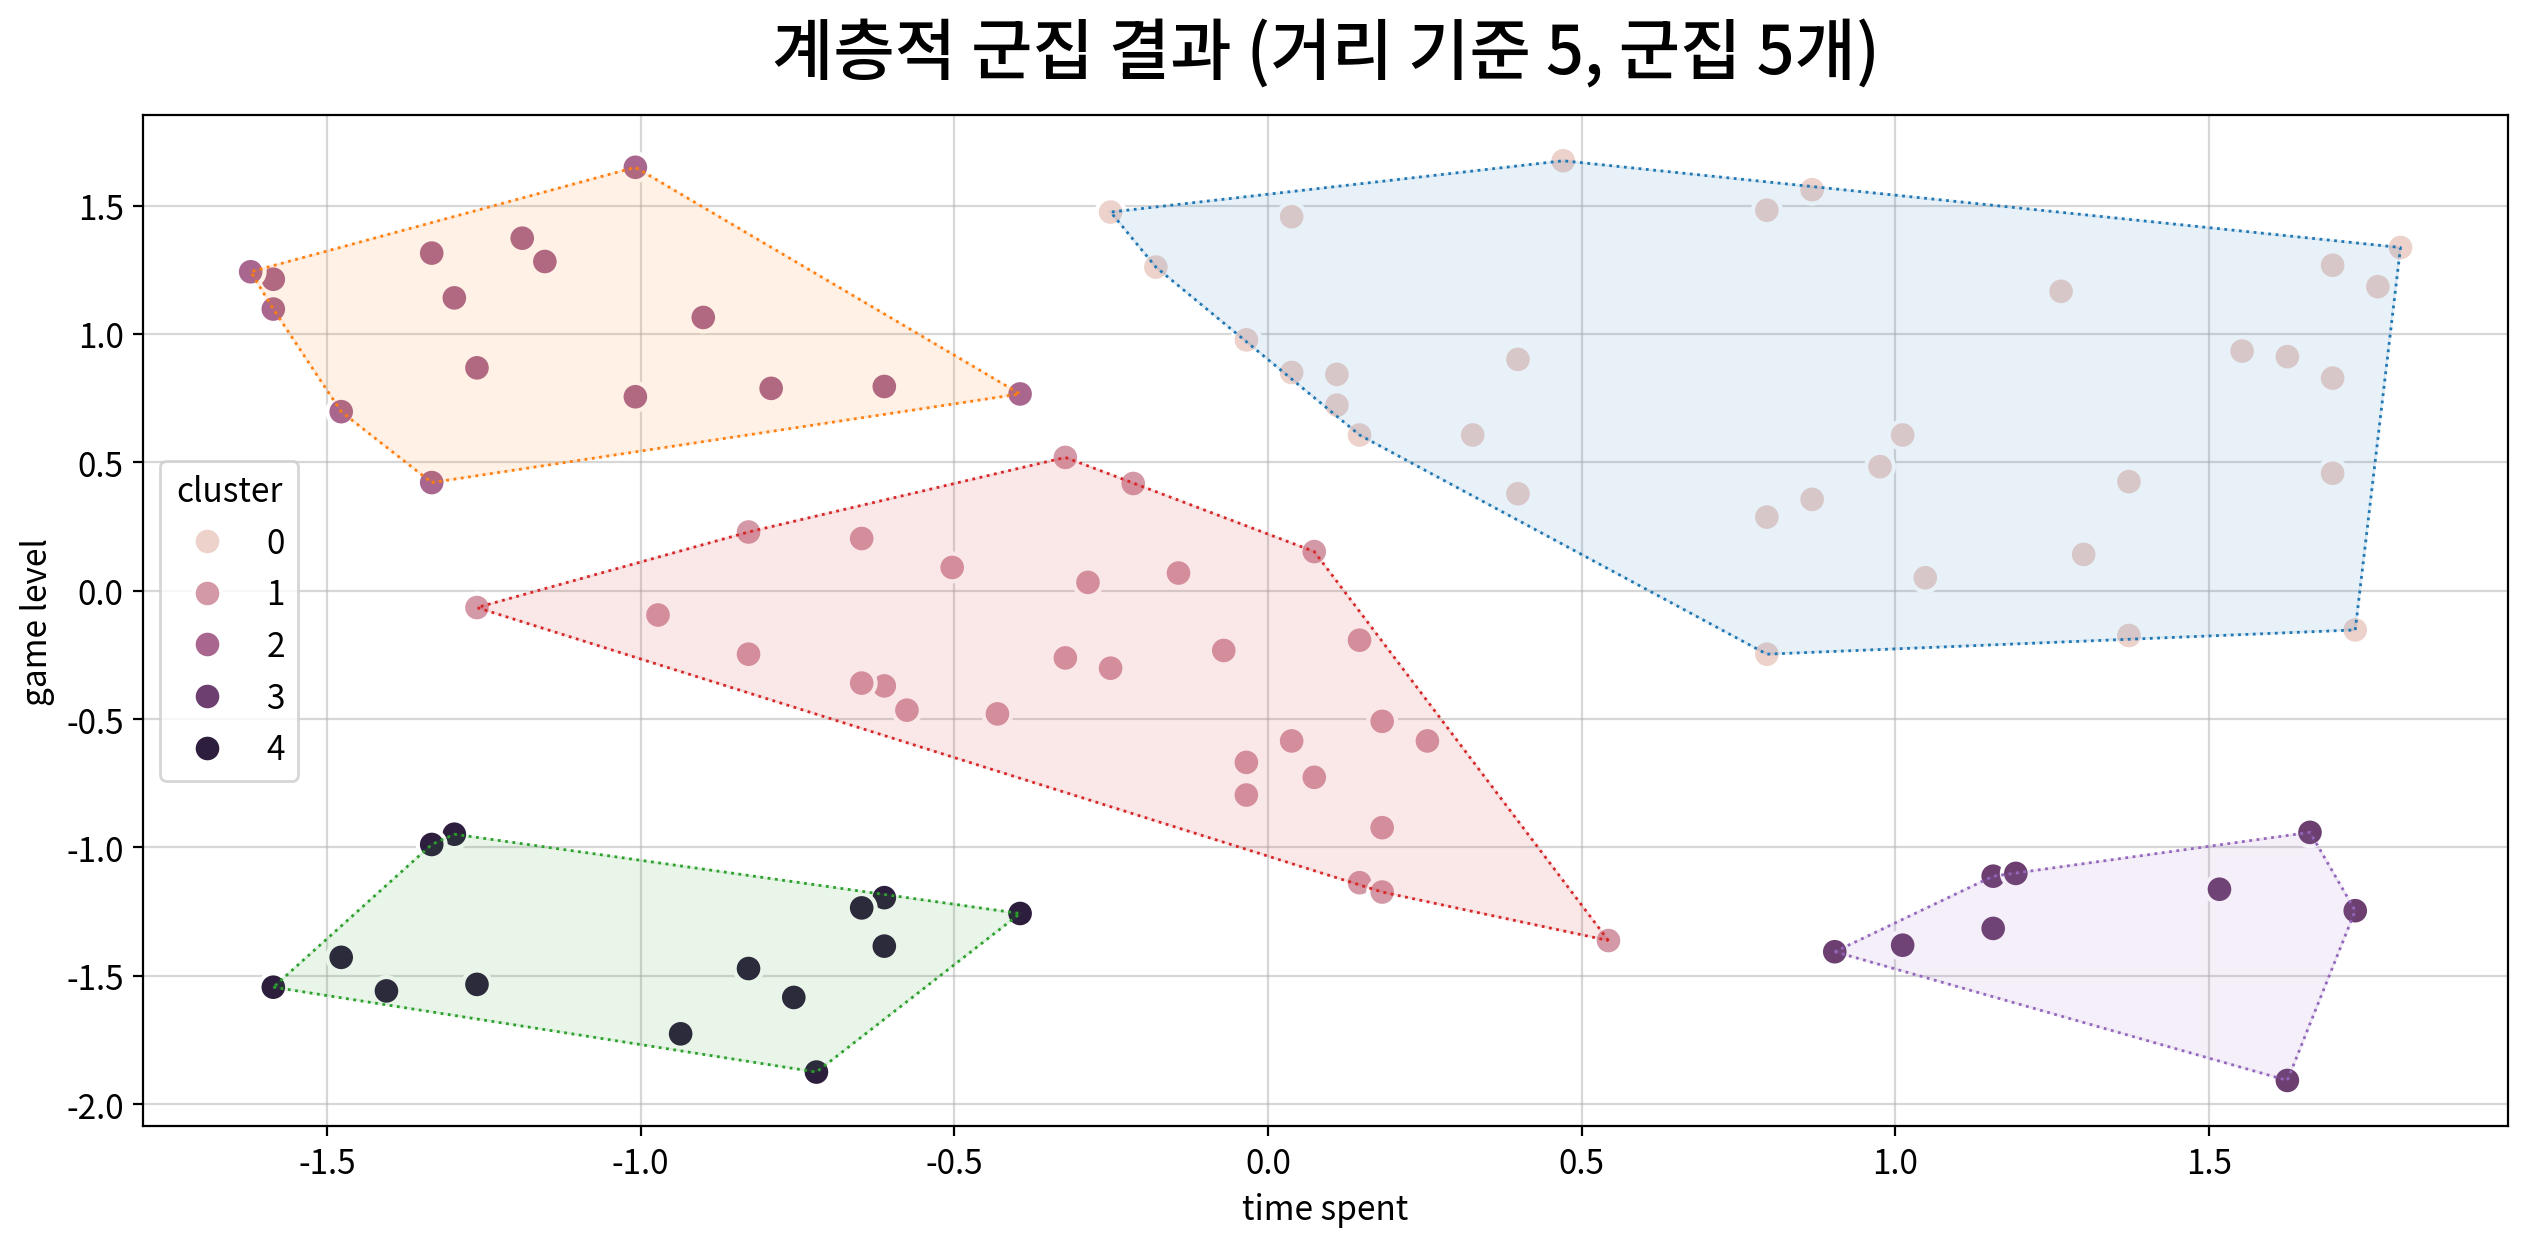

In [ ]:
my_plot.scatterplot(data=result_df, x="time spent", y="game level", hue="cluster",
                    outline=True,
                    title=f"계층적 군집 결과 (거리 기준 5, 군집 {estimator.n_clusters_}개)")

### 3. 실루엣 지수로 결과 확인

KeyboardInterrupt: 

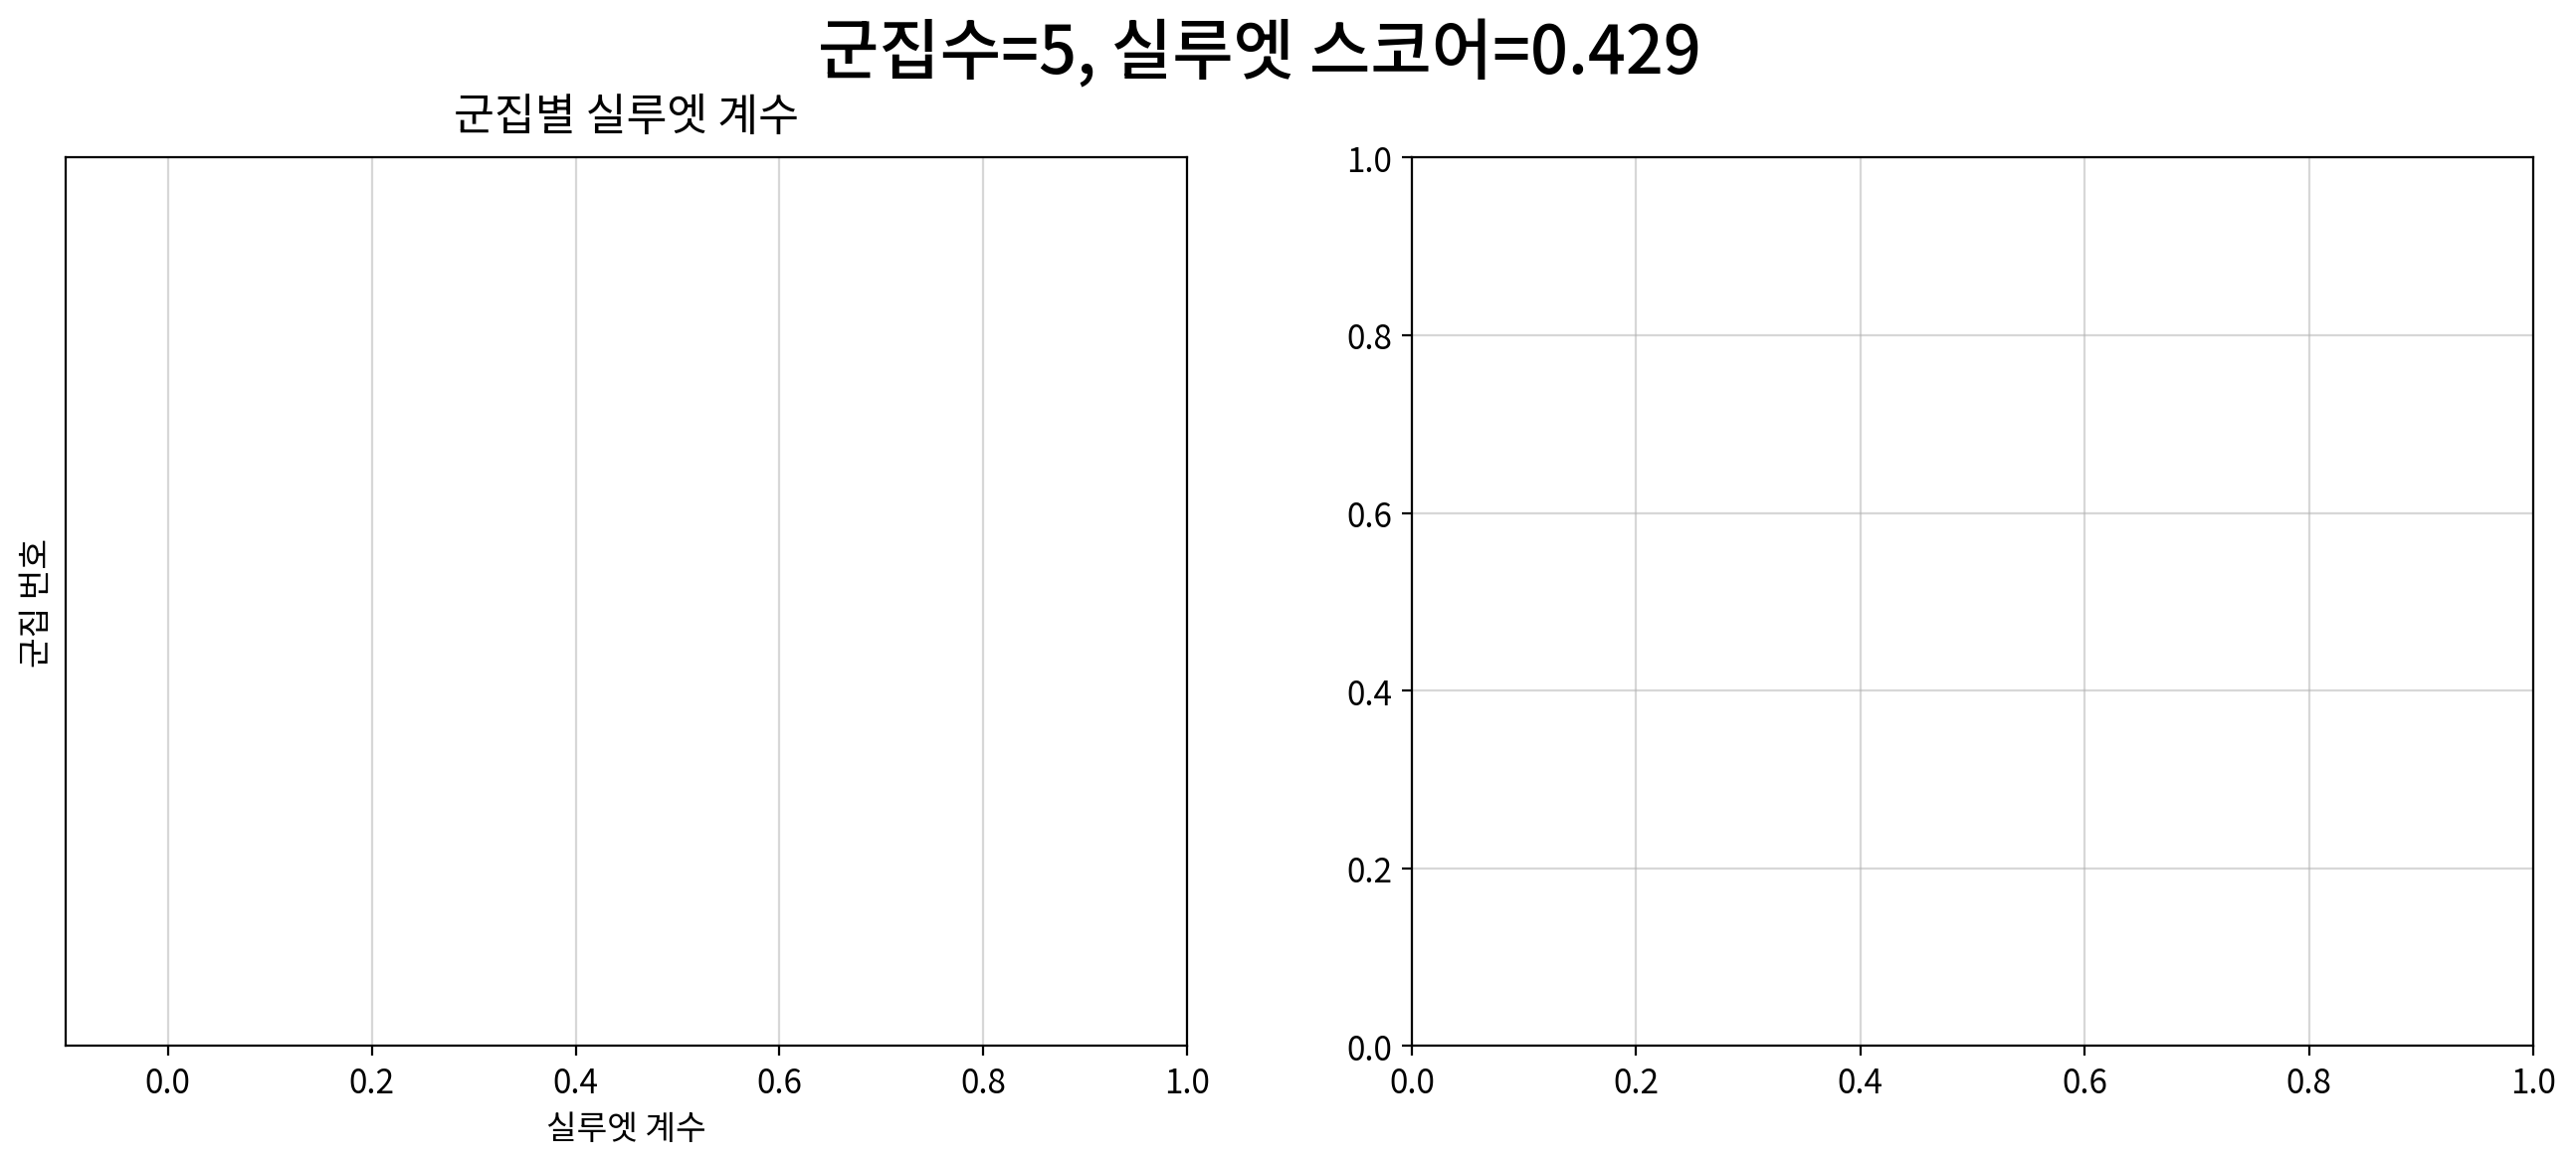

In [ ]:
my_cluster.visualize_silhouette(estimator=estimator, data=sdf)

> 실루엣 점수가 그리 높지는 않다.
>
> 실루엣은 **동글동글한 그룹**을 전제로 만든 지표라서, 모양이 복잡한 군집에는 잘 맞지 않는다.
> 그래서 점수만 믿지 말고 **그림을 함께 보고 분석가가 판단**해야 한다.

## #03. 덴드로그램

### 1. 덴드로그램용 데이터 만들기

sklearn에는 덴드로그램을 바로 그리는 기능이 없어서, 모델이 가진 정보를 조합해 주는 함수가 필요하다.

In [ ]:
data = my_cluster.dendrogram_source(estimator)
data[:5]

array([[3.60000000e+01, 8.70000000e+01, 3.76869846e-02, 2.00000000e+00],
       [5.10000000e+01, 9.80000000e+01, 3.76869846e-02, 2.00000000e+00],
       [2.50000000e+01, 4.20000000e+01, 4.63269855e-02, 2.00000000e+00],
       [8.00000000e+00, 3.70000000e+01, 5.11987456e-02, 2.00000000e+00],
       [1.20000000e+01, 1.70000000e+01, 5.38374037e-02, 2.00000000e+00]])

### [3] 덴드로그램 시각화

| 파라미터 | 의미 | ⭐ 추천값 |
|---|---|---|
| `data` | 위에서 만든 병합 정보 | 필수 |
| `truncate_mode` | 너무 빽빽할 때 줄여서 표시 | **`'lastp'`** |
| `p` | `lastp` 와 함께 — 마지막 몇 개까지 보여줄지 | **20~50** |
| `leaf_rotation` | X축 글자 회전 각도 | `0` 또는 `90` |
| `leaf_font_size` | X축 글자 크기 | `6~10` |
| `count_sort` | 가지의 정렬 순서 | `'ascending'` |

- **`truncate_mode`**
    - `None` : 전체를 다 그린다 (데이터가 많으면 읽을 수 없다)
    - **`'lastp'`** ⭐ : 마지막 `p`개의 가지만 보여준다. X축에 `(3)`, `(5)` 처럼 **묶인 개수**가 표시된다

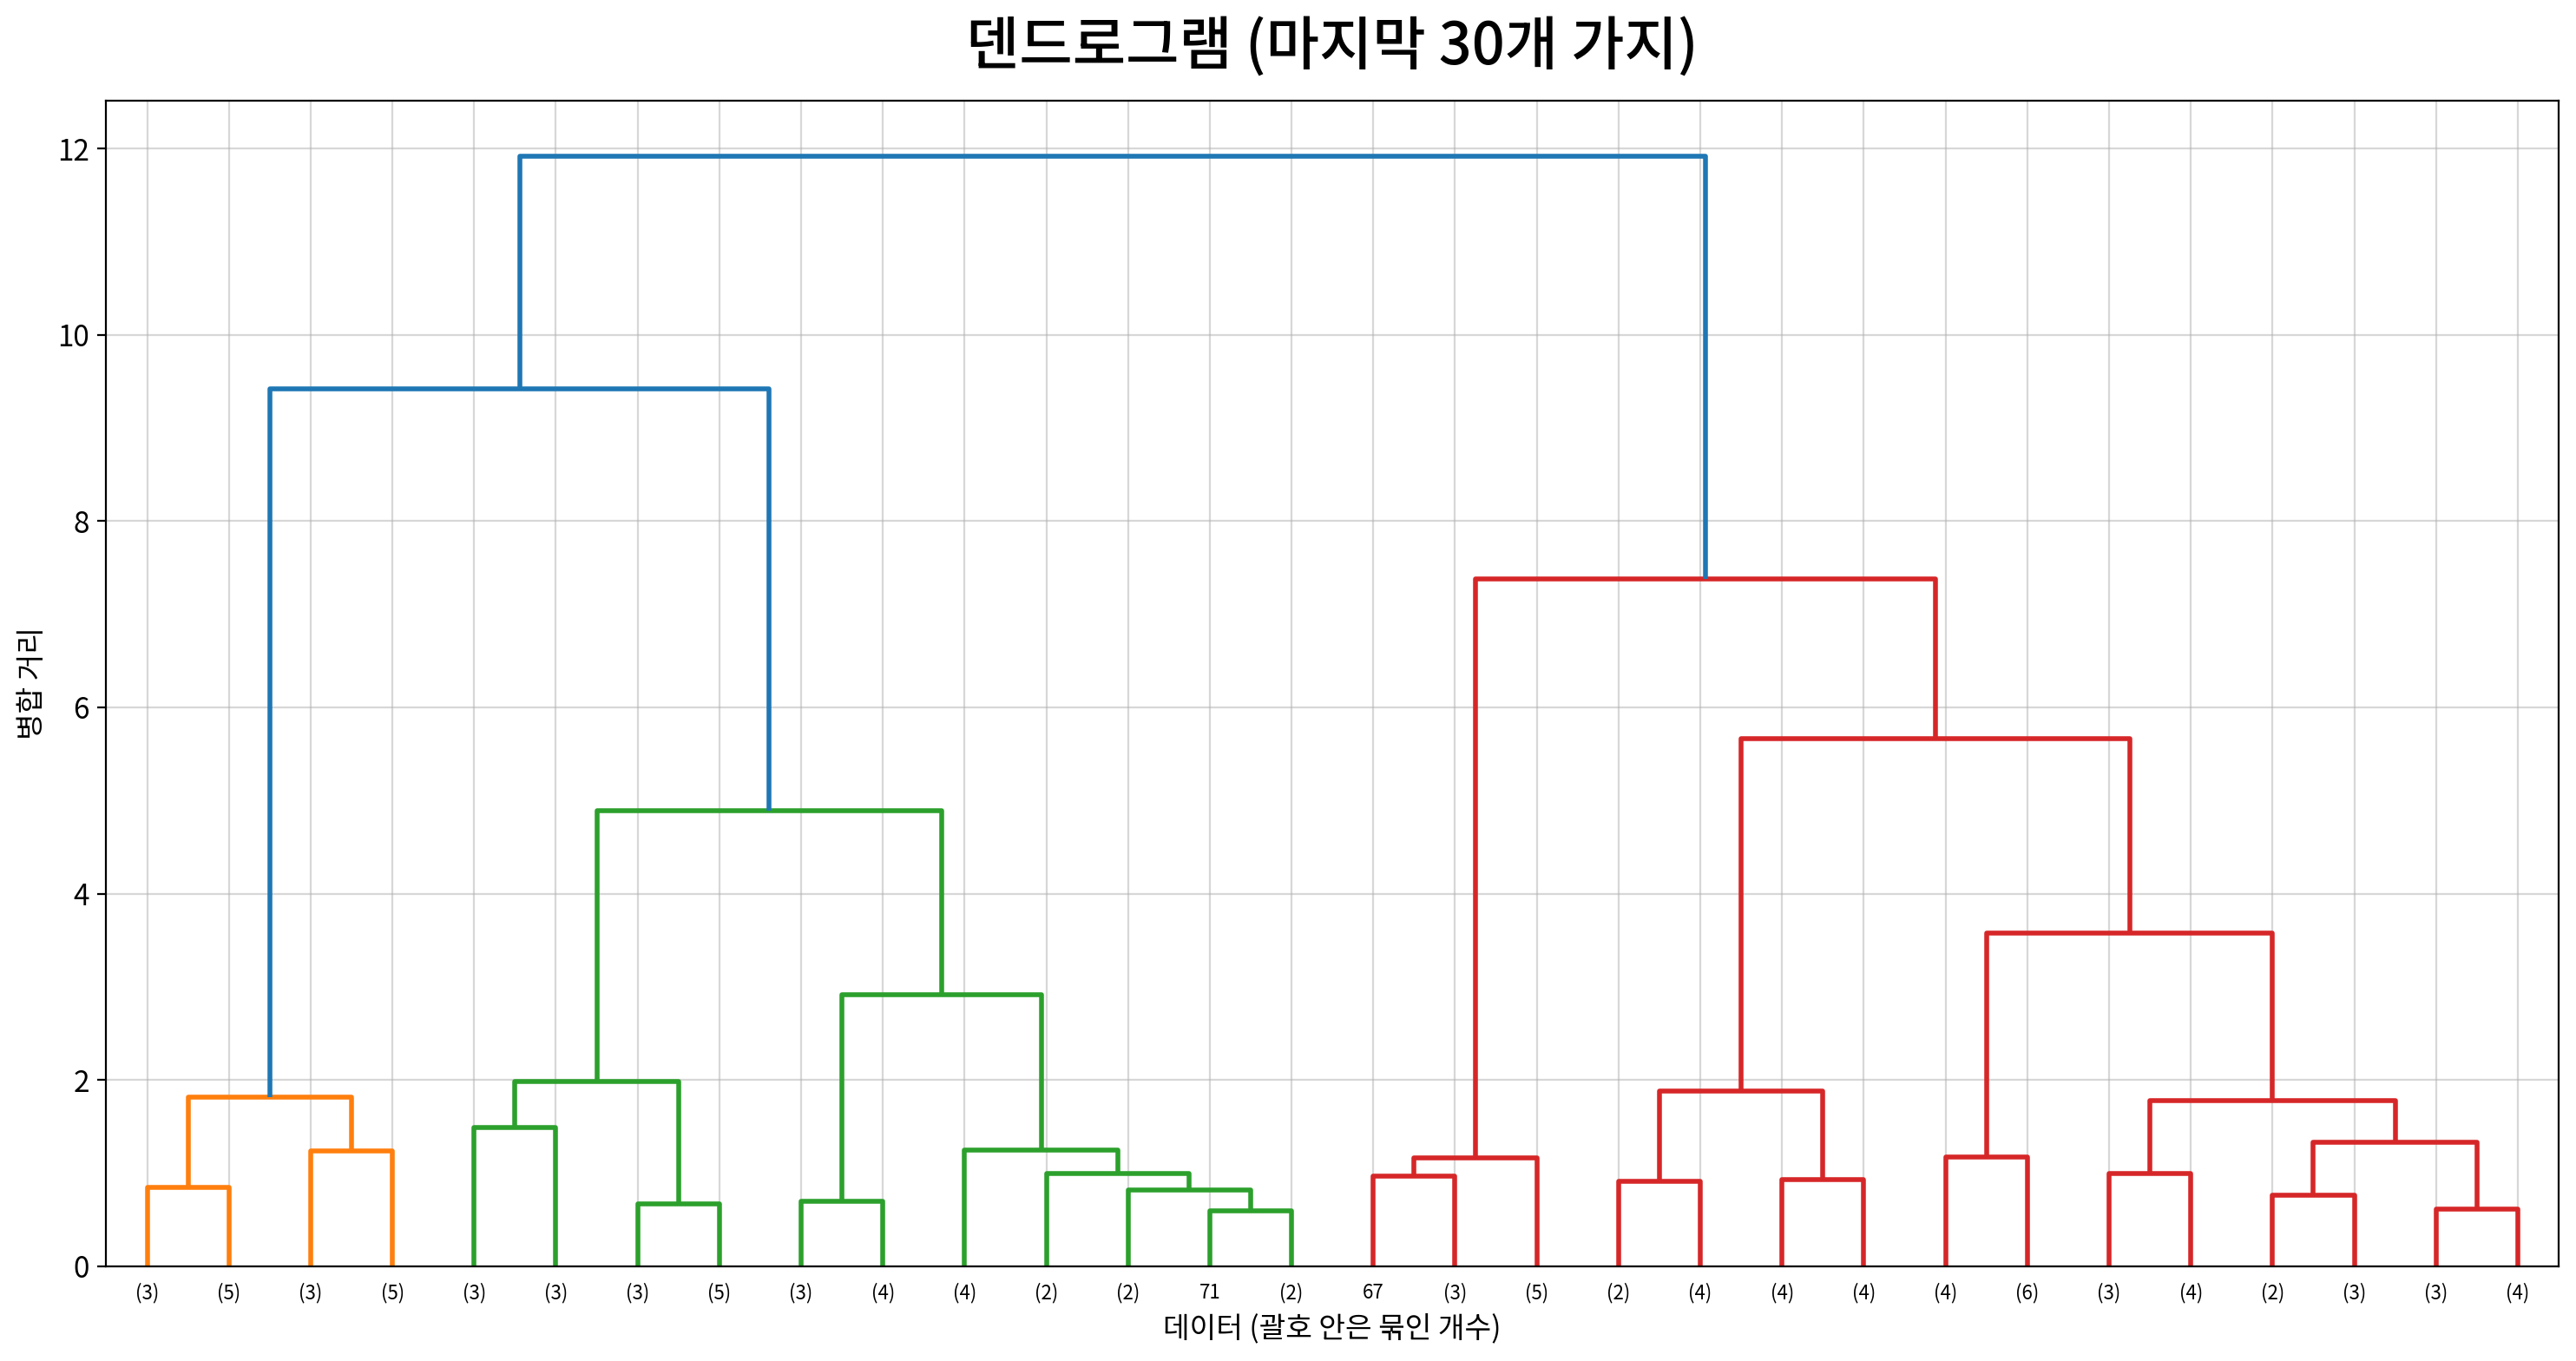

In [ ]:
fig, ax = my_plot.init(width=1500, height=800, title="덴드로그램 (마지막 30개 가지)")

dendrogram(
    data,
    ax=ax,
    p=30,
    truncate_mode="lastp",
    leaf_rotation=0,
    leaf_font_size=8,
    count_sort="ascending",
)

ax.set_xlabel("데이터 (괄호 안은 묶인 개수)")
ax.set_ylabel("병합 거리")

my_plot.show()

#### `x` 축 해석

덴드로그램 X축의 괄호 숫자는 **"이 가지 아래에 데이터가 몇 개 들어 있나"** 를 뜻한다.

| X축 표시 | 의미 |
| --- | --- |
| `3` | 3번 데이터 1개 (개별 샘플) |
| `(3)` | 데이터 **3개가 이미 묶인** 그룹 |
| `(5)` | 데이터 **5개가 묶인** 그룹 |

처음에는 모든 데이터가 개별 노드라서 괄호가 없지만, 병합이 진행되면 **대표 노드 + (포함된 개수)** 로 표시된다.

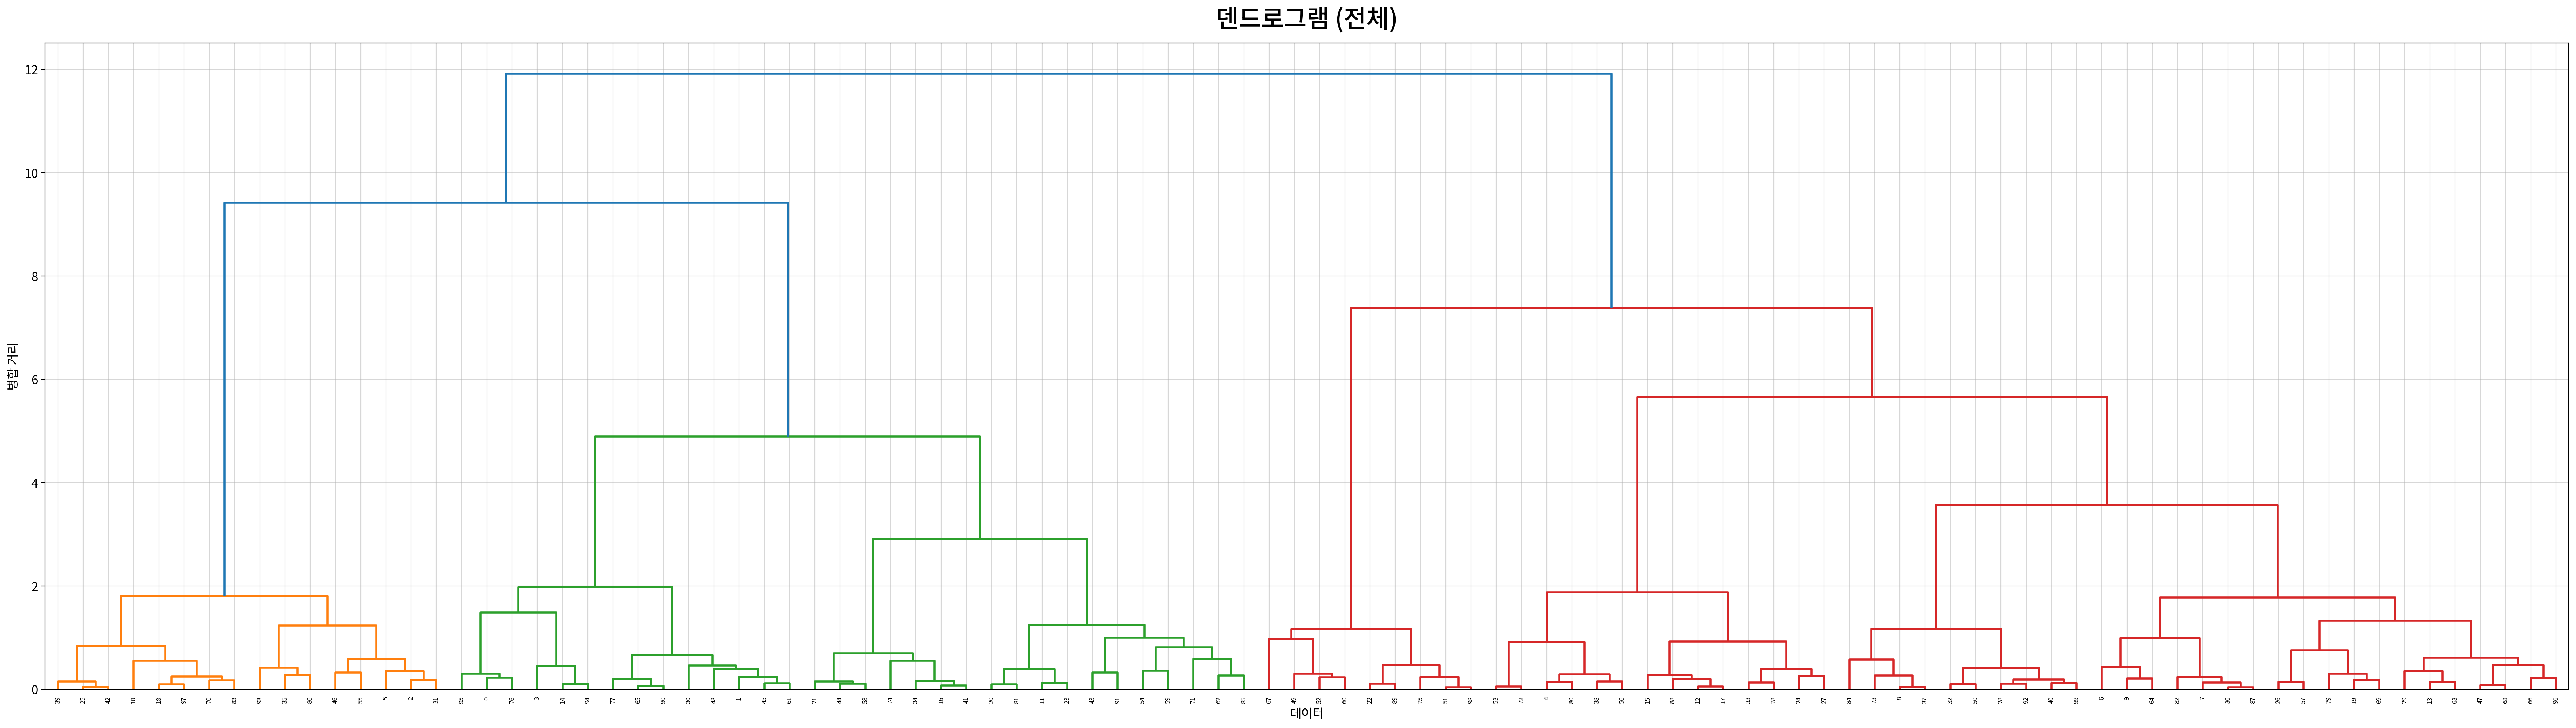

In [ ]:
fig, ax = my_plot.init(width=3500, height=1000, title="덴드로그램 (전체)")

dendrogram(
    data,
    ax=ax,
    truncate_mode=None,   # p를 무시하고 전체를 표시
    leaf_rotation=90,
    leaf_font_size=6,
    count_sort="ascending",
)

ax.set_xlabel("데이터")
ax.set_ylabel("병합 거리")

my_plot.show()

## #04. 모듈화 기능 확인

### 1. 덴드로그램

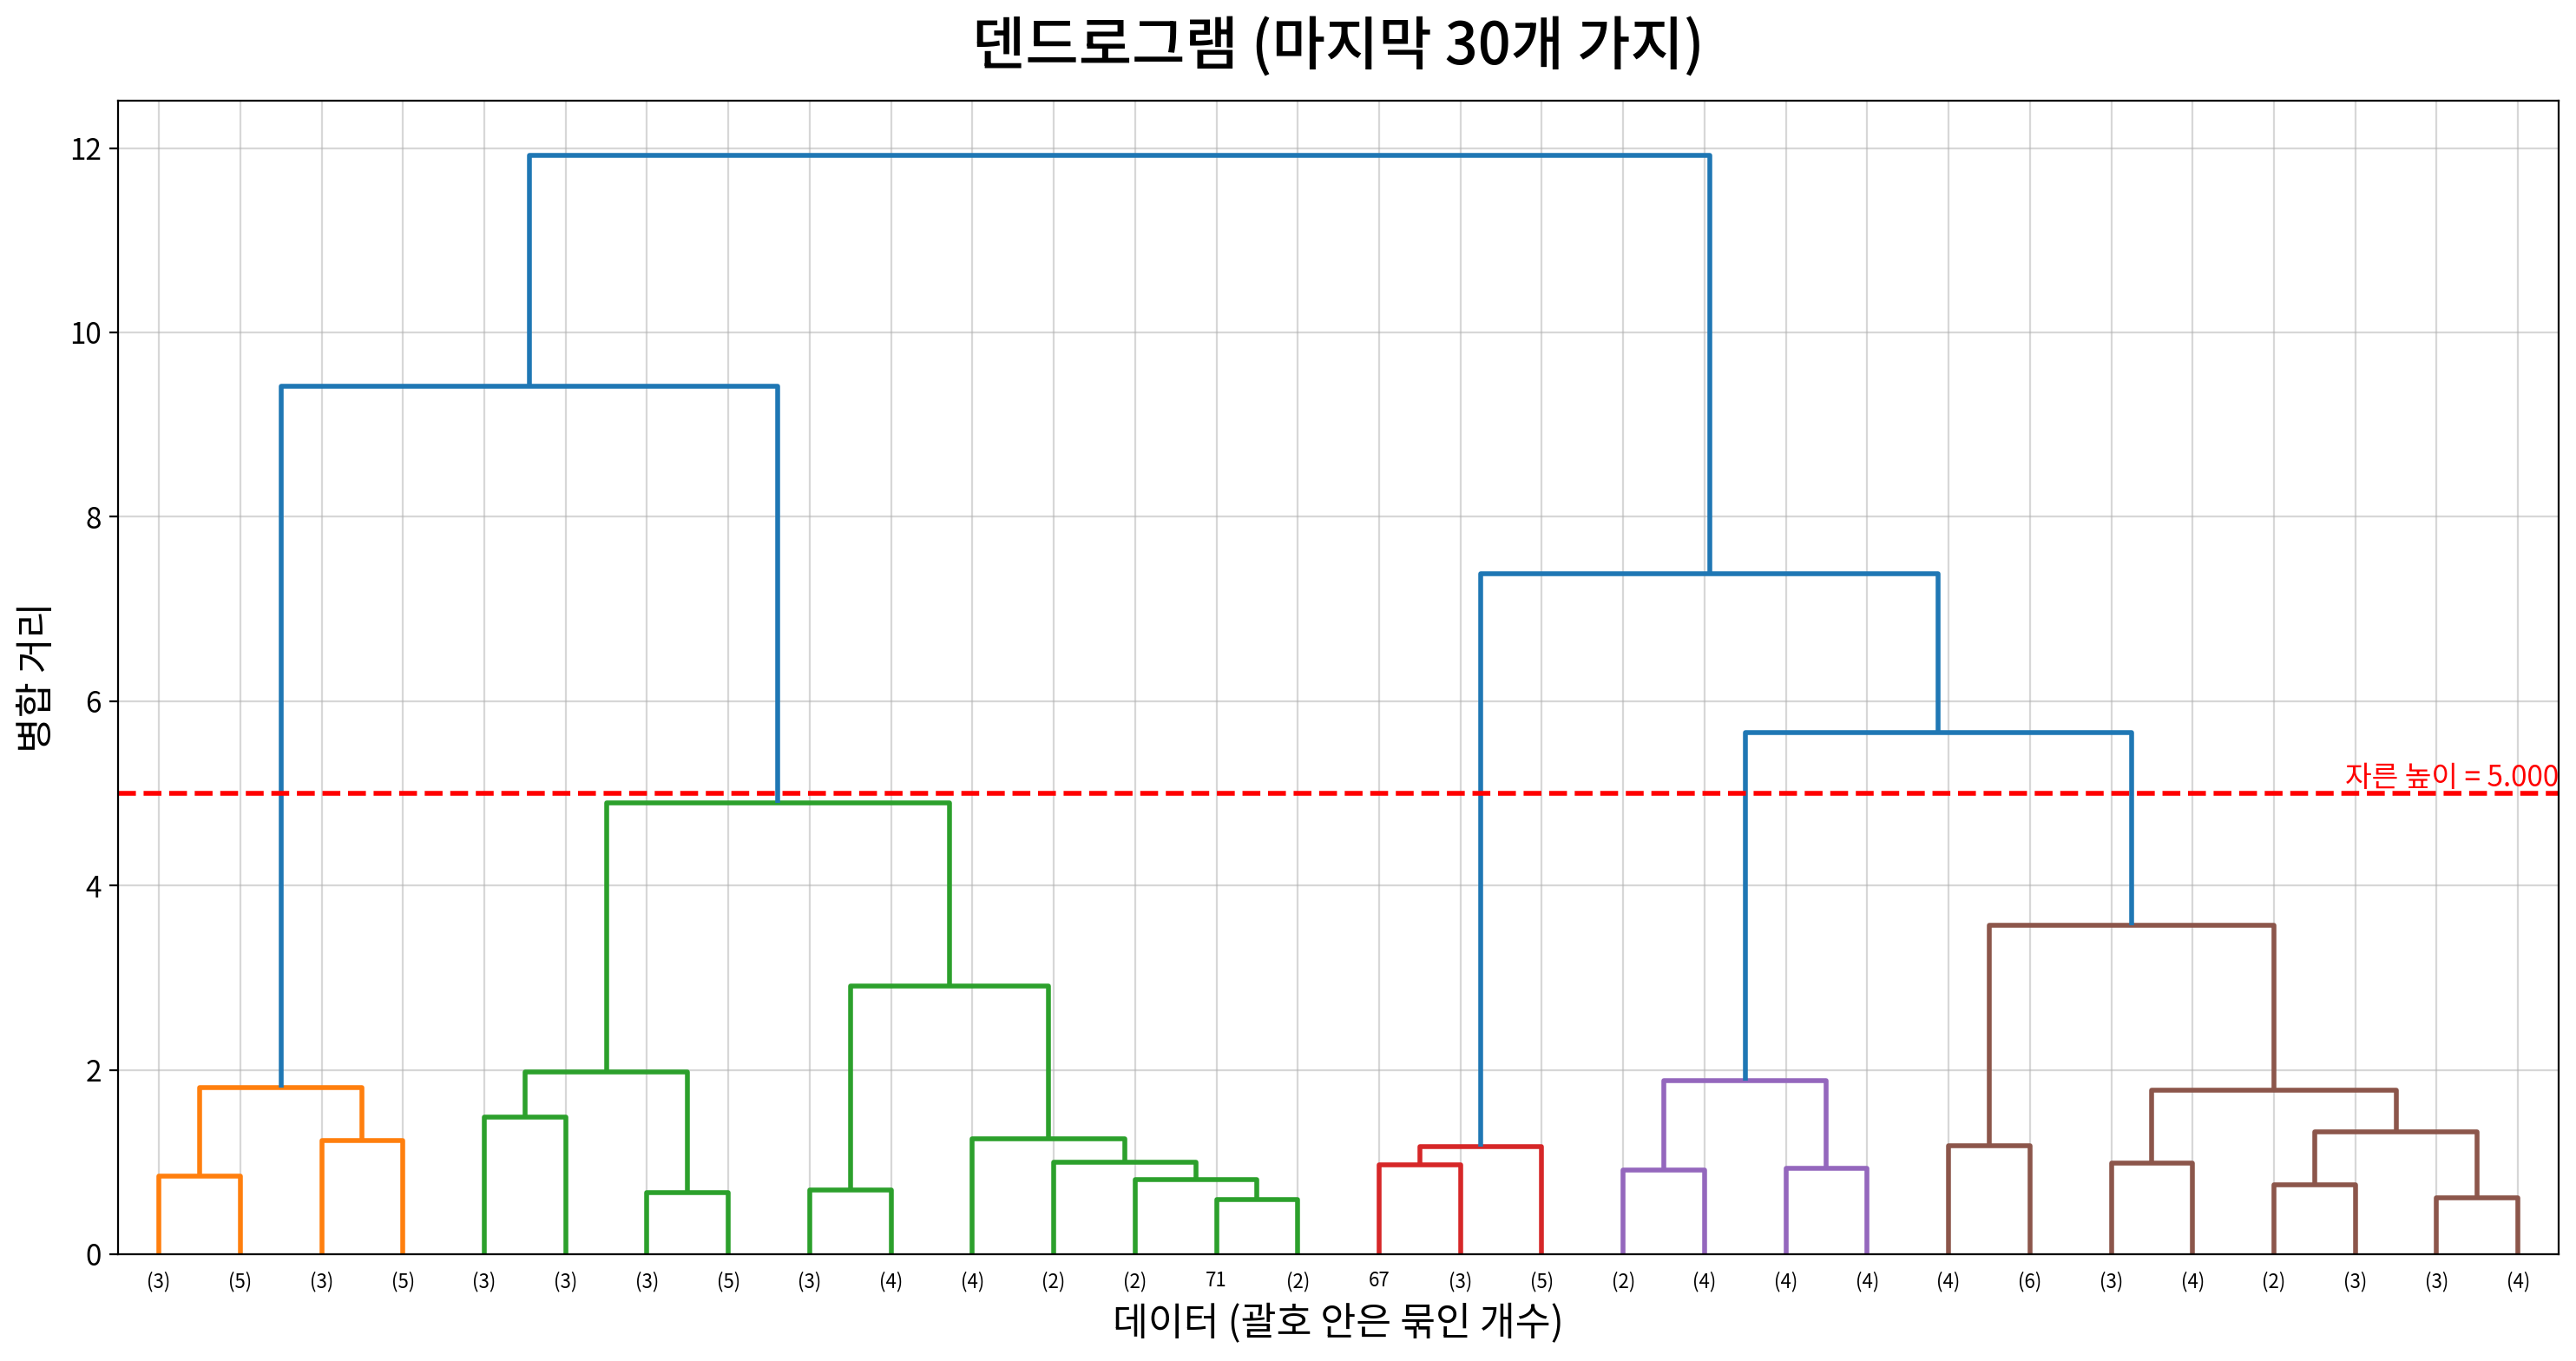

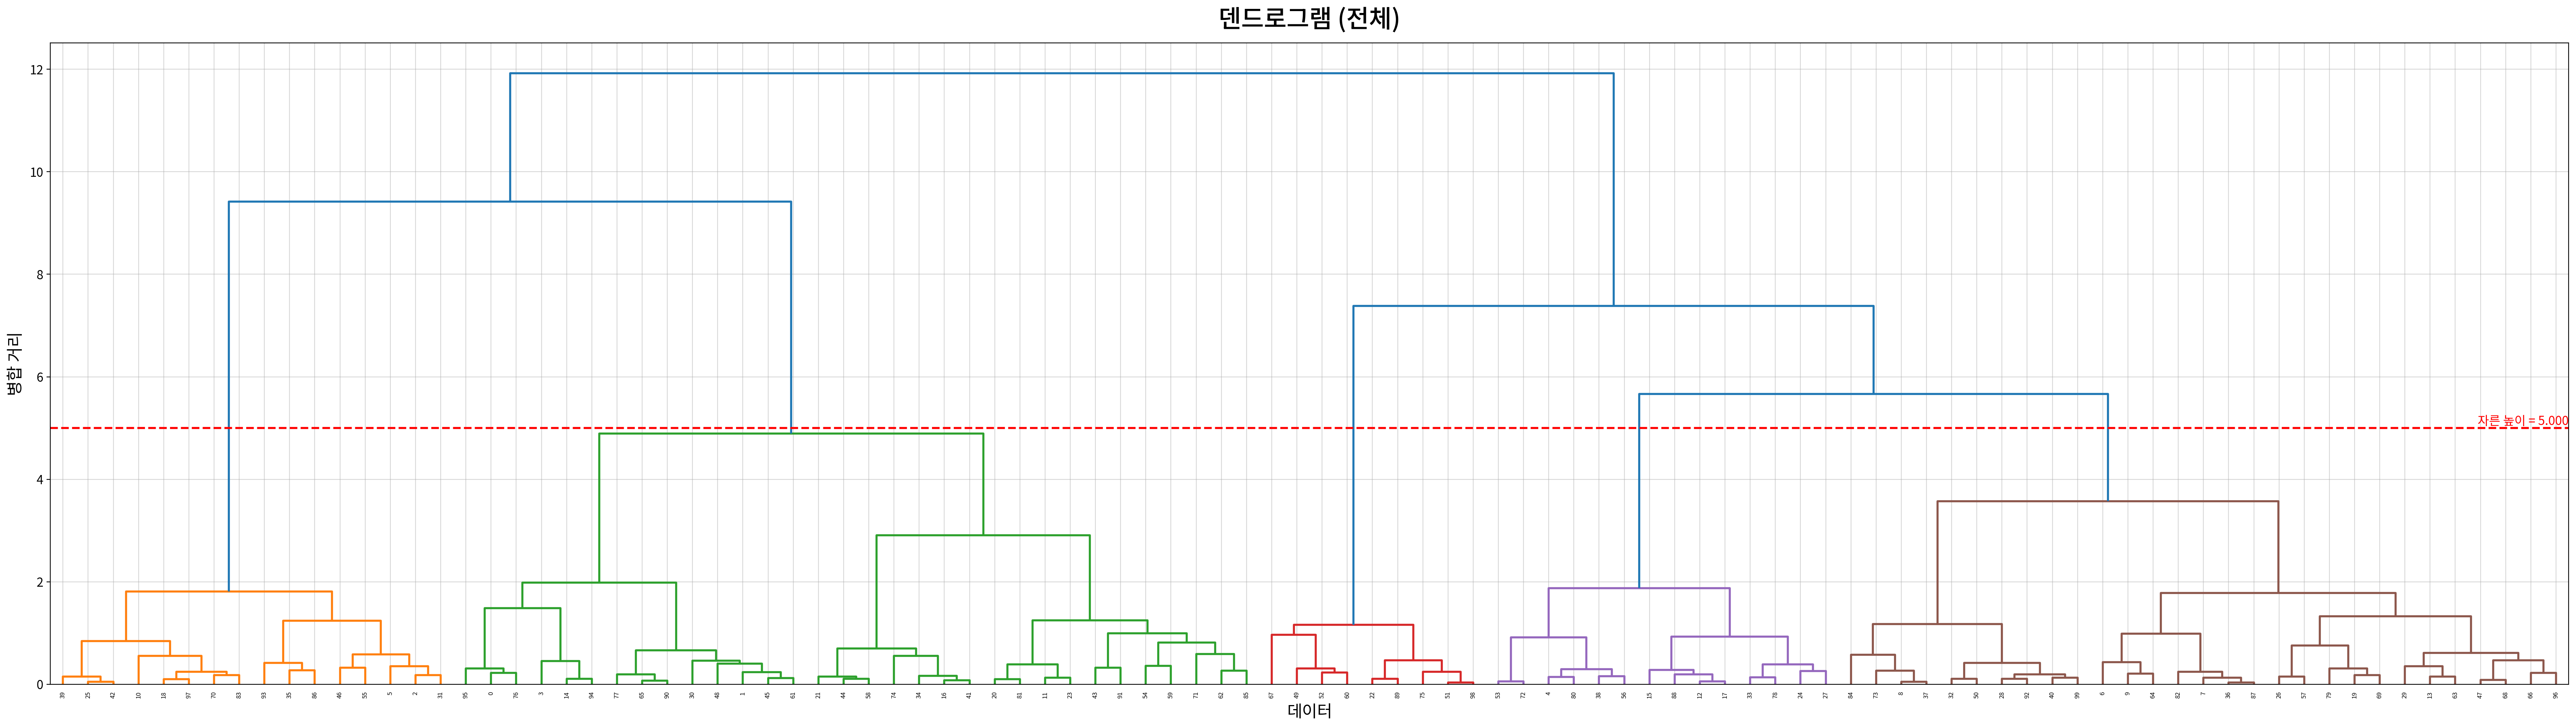

In [ ]:
# #03에서 한 일(linkage 행렬 만들기 → 캔버스 생성 → 그리기 → 축 이름 지정)을
# 모듈화 함수 하나가 대신한다
my_cluster.plot_dendrogram(estimator, title="덴드로그램 (마지막 30개 가지)",
                                width=1500, height=800)

# 전체를 보고 싶다면 가지를 생략하지 않도록 truncate_mode 를 None 으로 지정한다
my_cluster.plot_dendrogram(estimator, truncate_mode=None,
                                leaf_rotation=90, leaf_font_size=6,
                                title="덴드로그램 (전체)", width=3500, height=1000)

### 2. 거리 기준으로 자동 결정 (#02 와 같은 조건)

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67
[계층적 군집] 군집 수 = 5, 연결 방법 = ward, 거리 = euclidean
    · 자른 높이 (병합 거리) = 5.0000
    · 군집별 데이터 개수 : 0번 32개,1번 29개,2번 16개,3번 9개,4번 14개


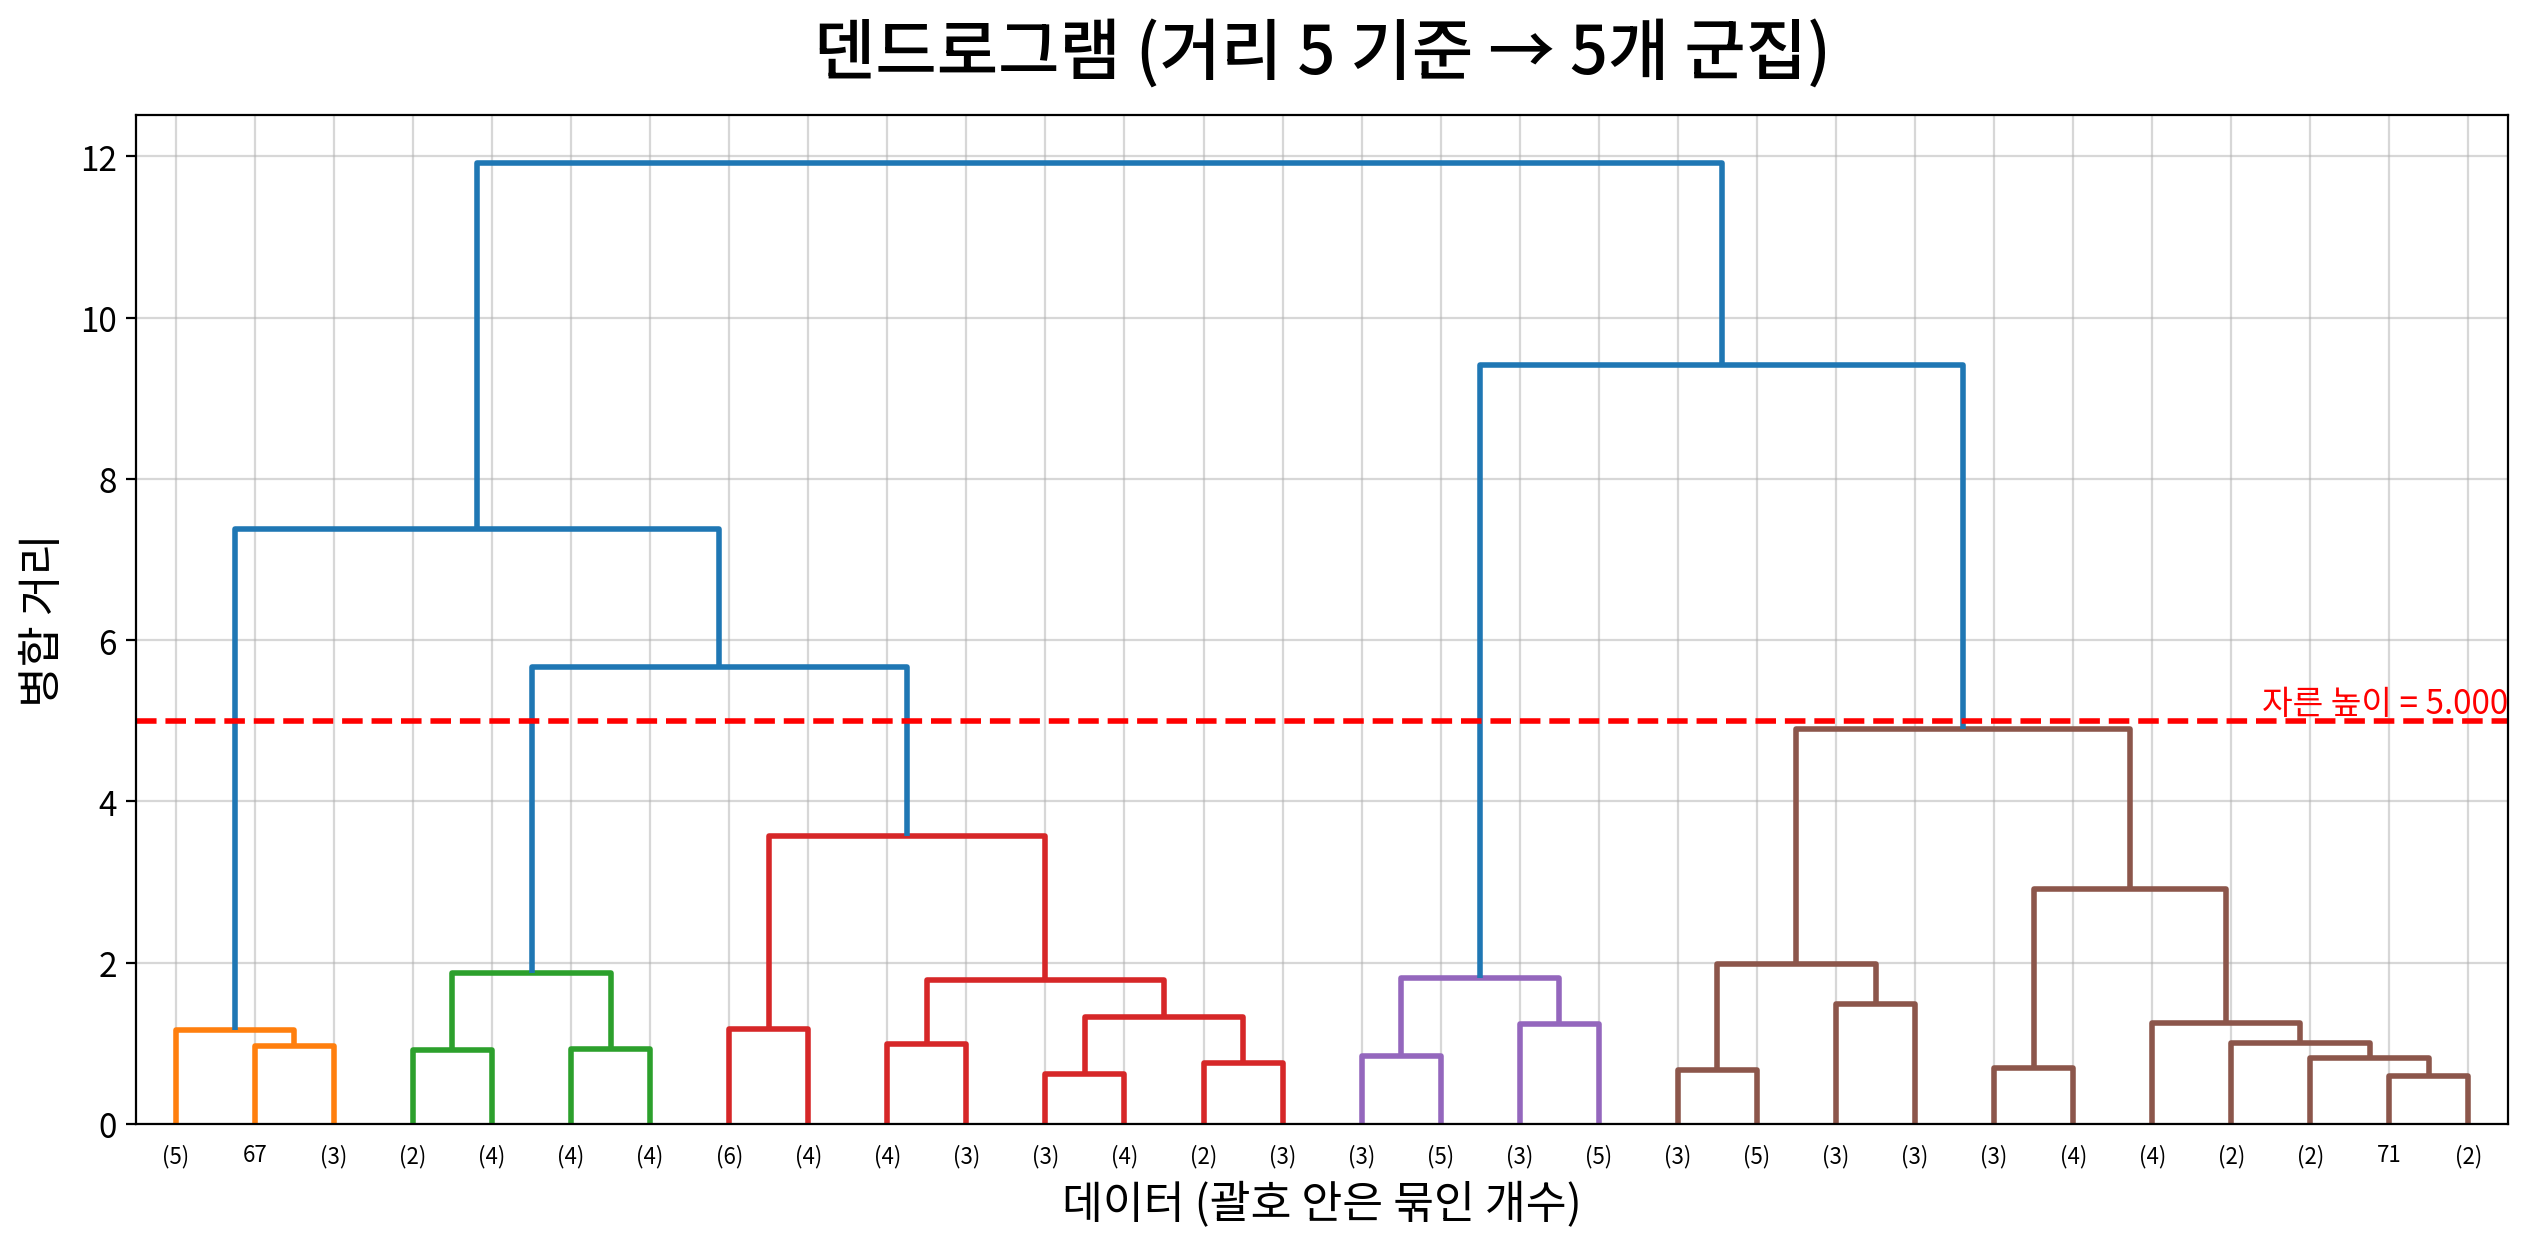

,time spent,game level,그룹번호
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


In [ ]:
# 스케일링(기본값 standard)까지 함수가 알아서 수행한다
estimator, df = my_cluster.agglomerative(origin, distance_threshold=5)
df.head()

> 덴드로그램의 빨간 점선이 **자른 높이(거리 5)** 다. 이 선과 만나는 가지의 수가 곧 군집 수가 된다.

### 3. 군집 수를 직접 지정

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67
[계층적 군집] 군집 수 = 4, 연결 방법 = ward, 거리 = euclidean
    · 자른 높이 (병합 거리) = 9.3546
    · 군집별 데이터 개수 : 0번 43개,1번 32개,2번 16개,3번 9개


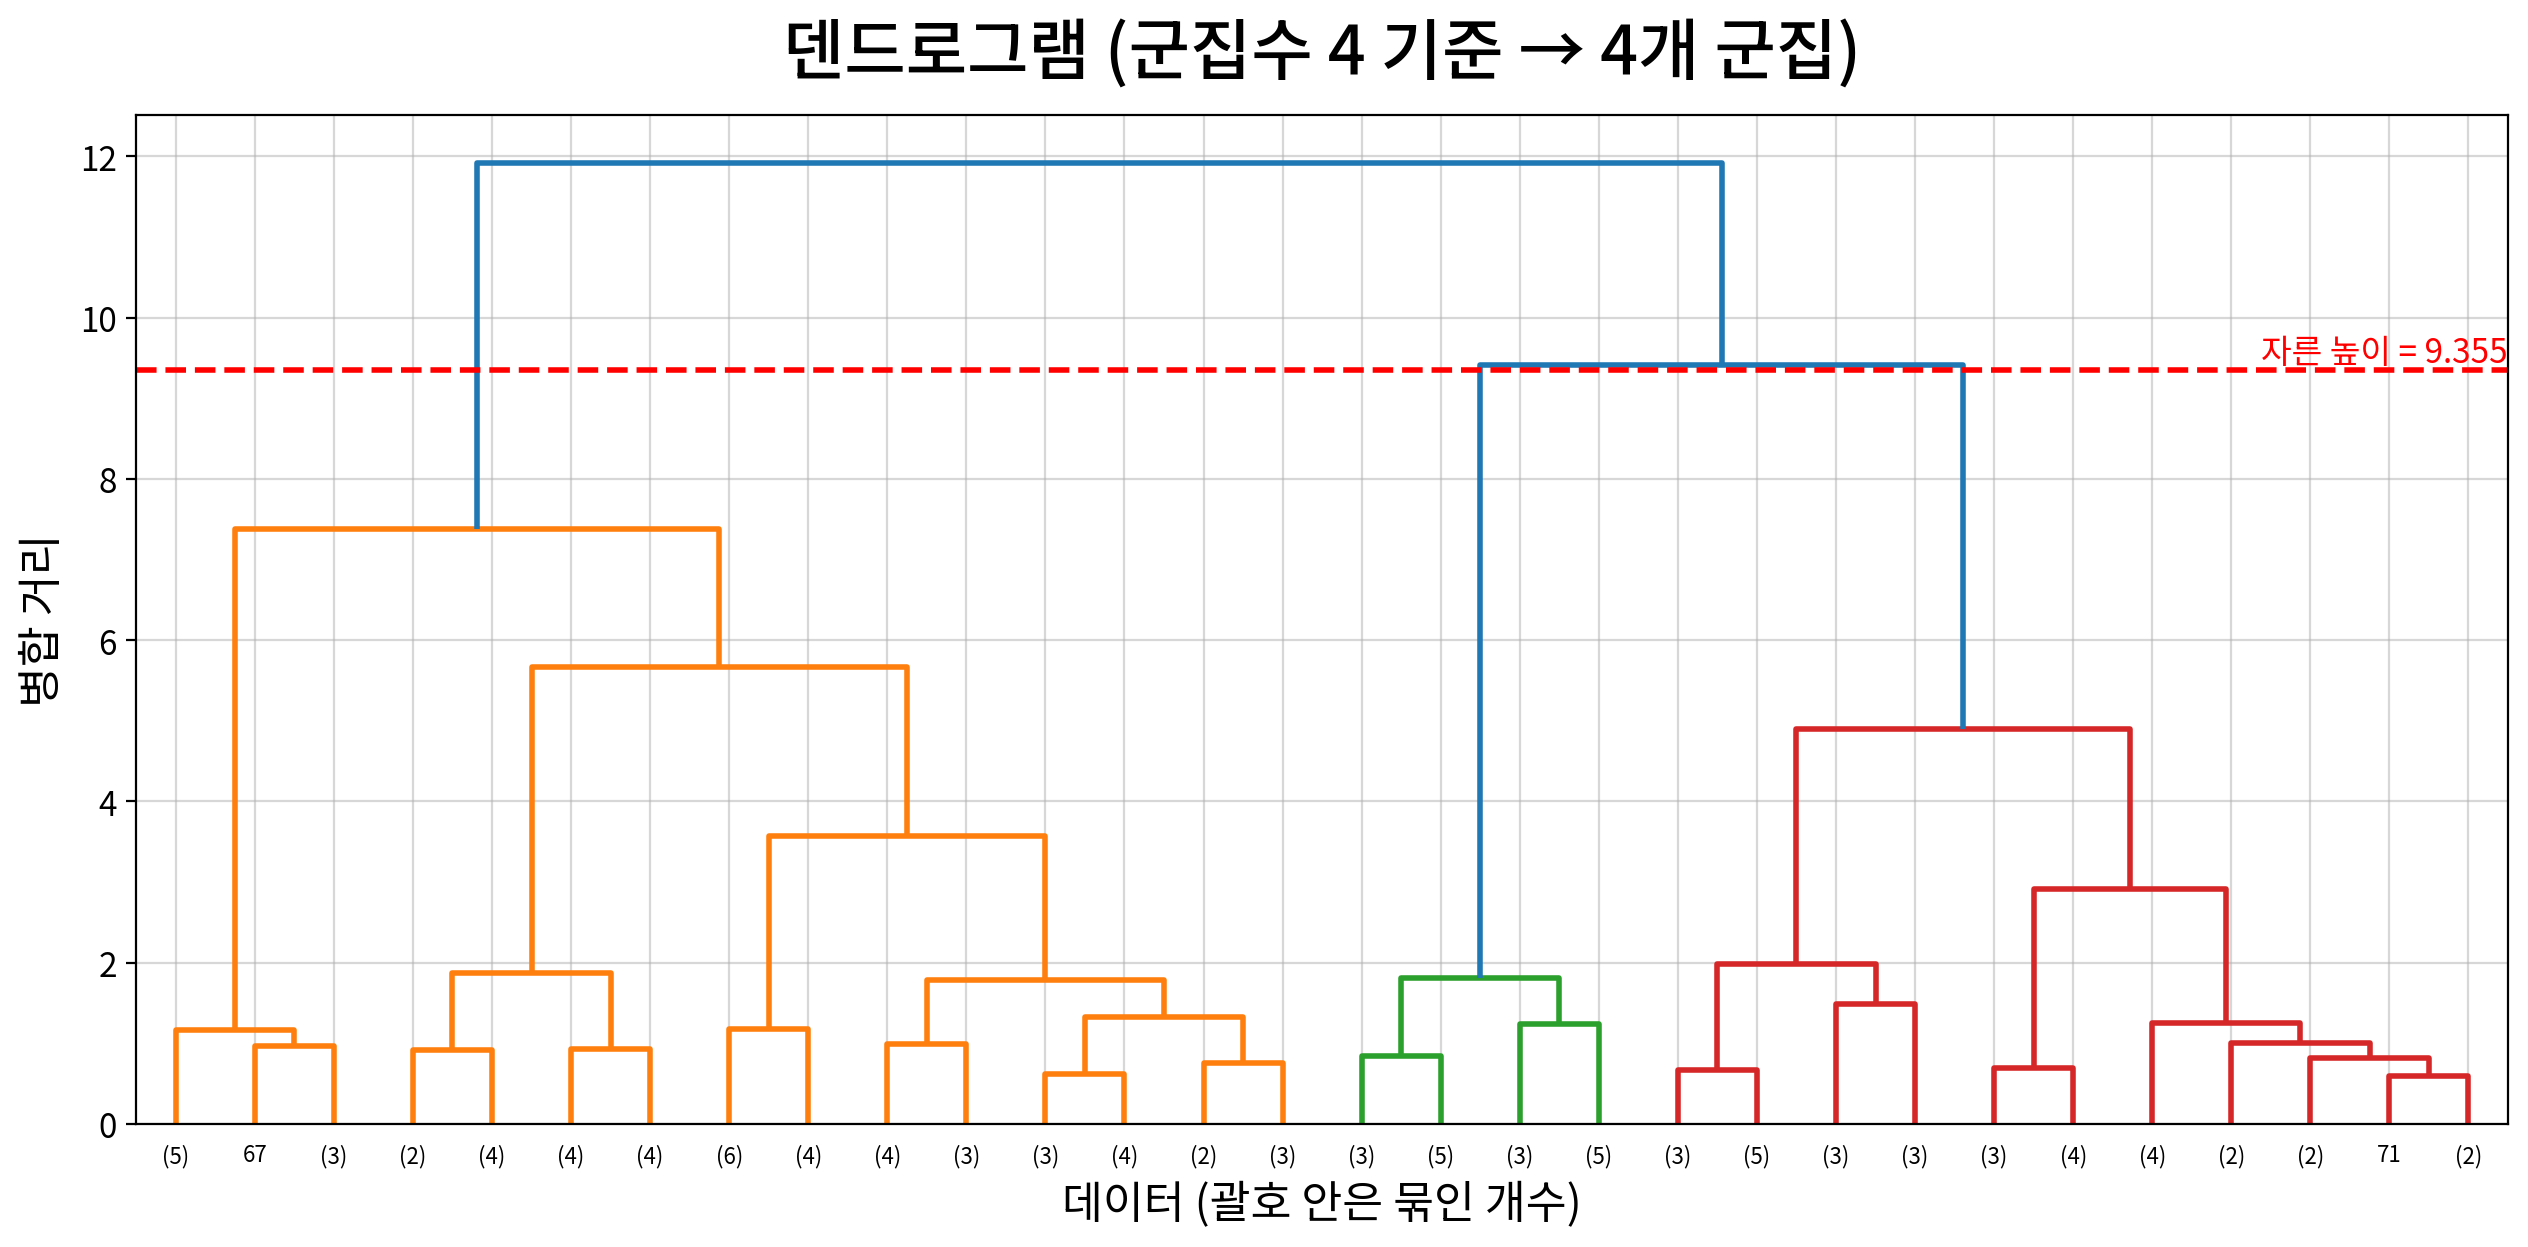

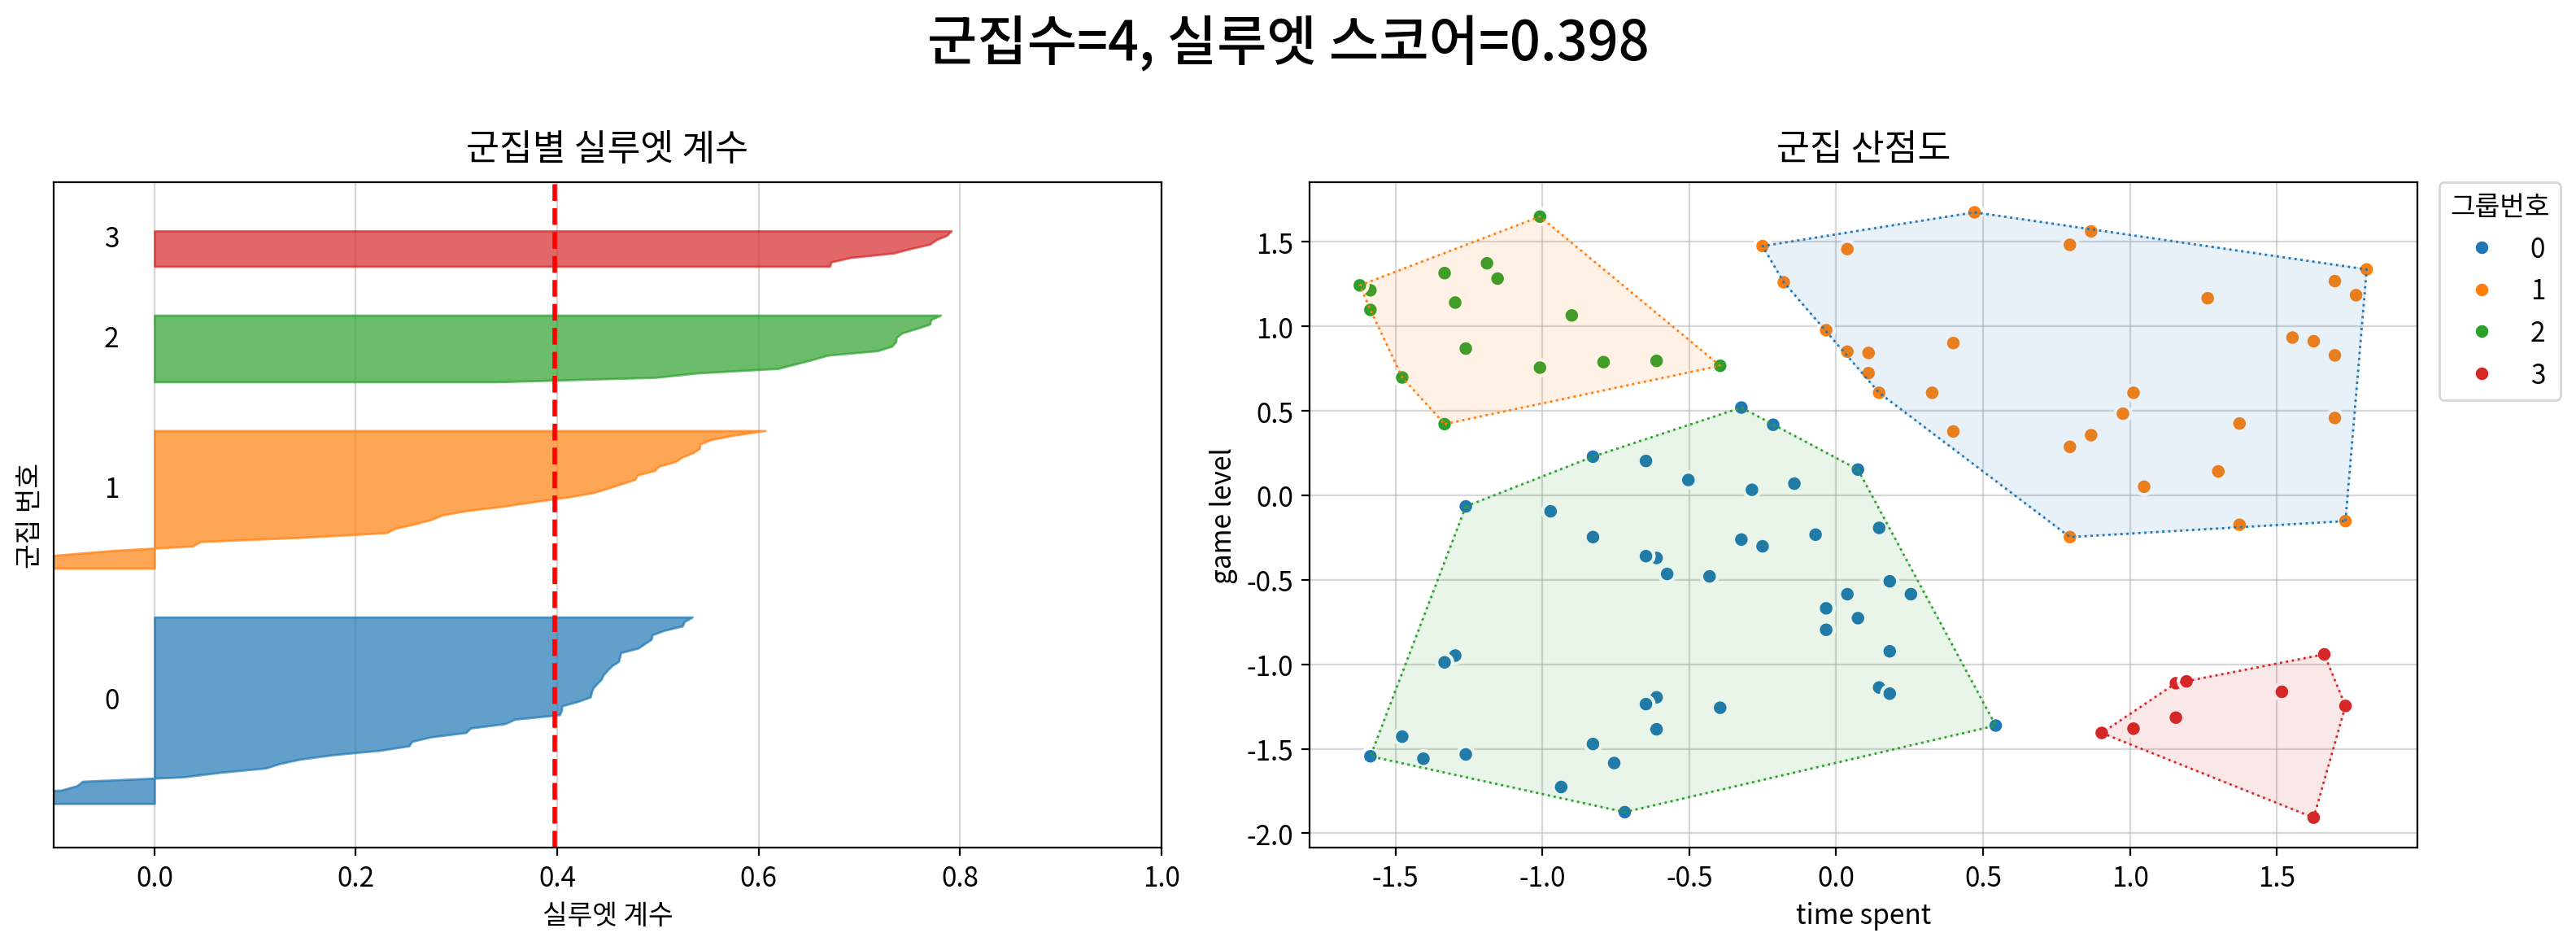

In [ ]:
estimator, df = my_cluster.agglomerative(origin, k=4)

# 실루엣 지수도 함께 확인 (군집번호 컬럼은 함수가 알아서 제외한다)
my_cluster.visualize_silhouette(estimator=estimator, data=df)

### 4. 연결 방법 변경 + 덴드로그램 전체 표시

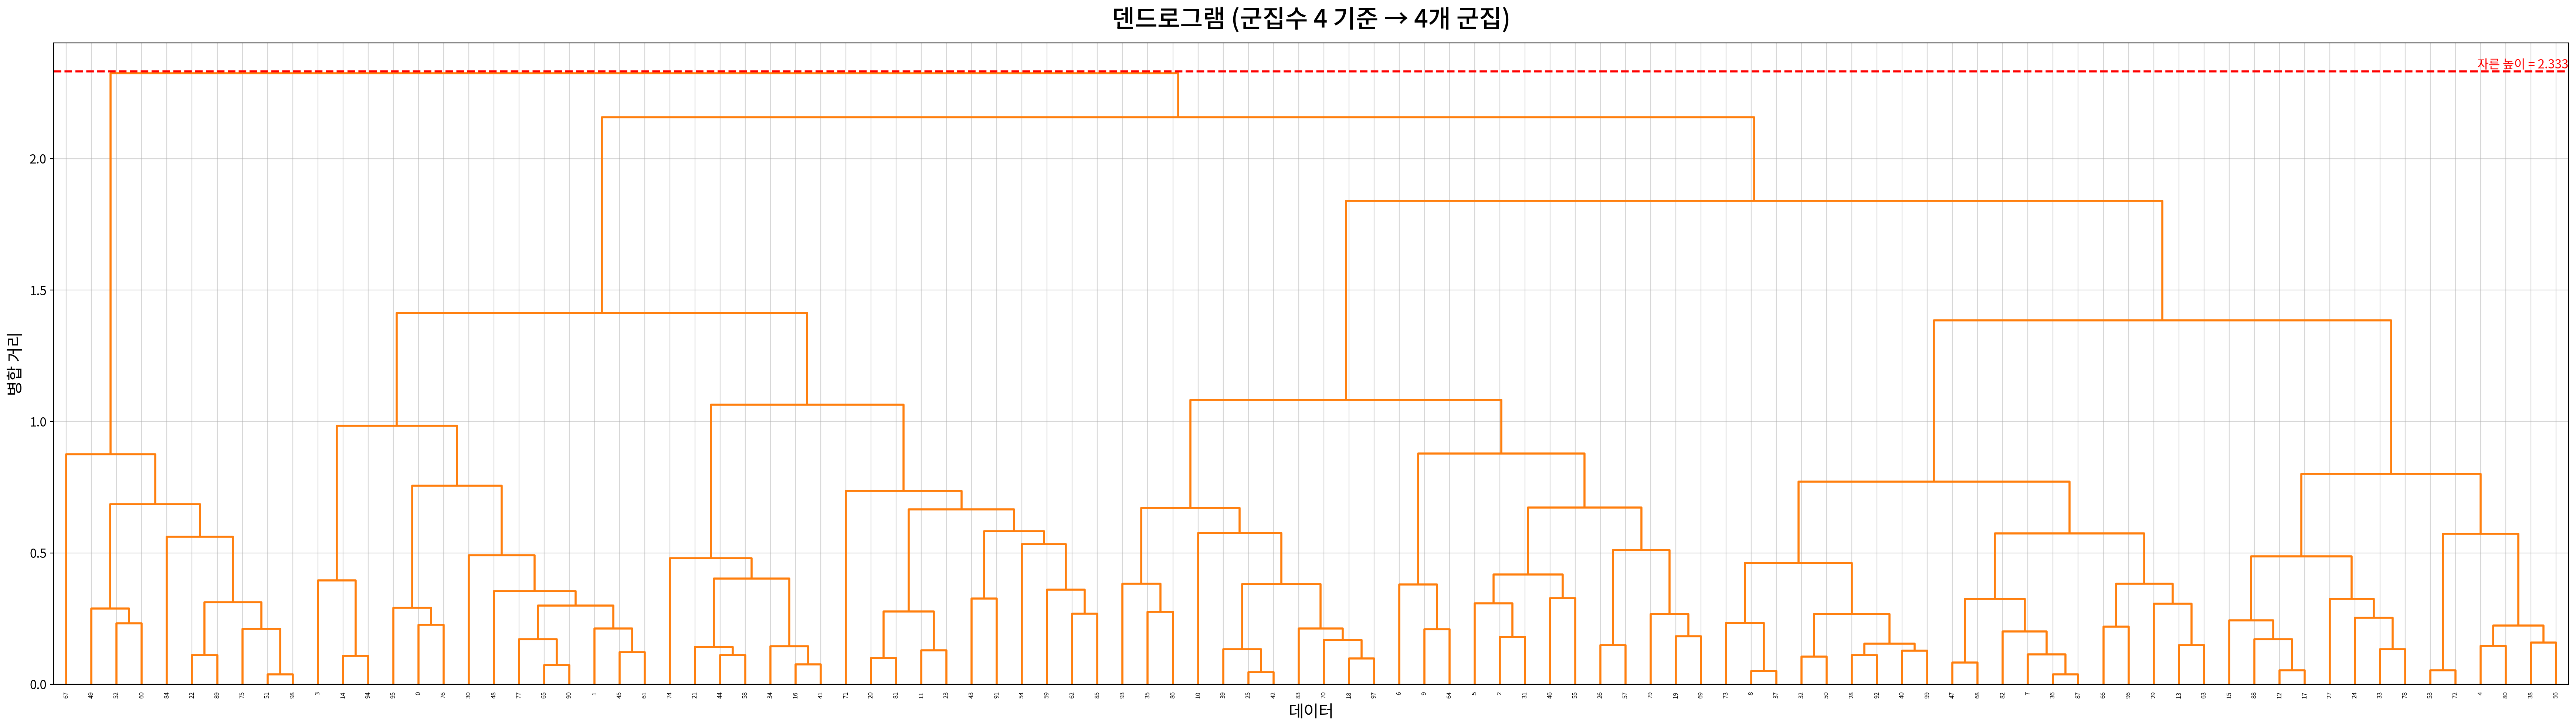

In [ ]:
estimator, df = my_cluster.agglomerative(origin, k=4,
                        linkage="average",     # 두 덩어리의 모든 쌍의 평균 거리로 합친다
                        truncate_mode=None,    # 가지를 생략하지 않고 전체를 표시
                        leaf_rotation=90, leaf_font_size=6,
                        width=3500, height=1000, verbose=False)

> 연결 방법(`linkage`)을 바꾸면 합쳐지는 순서가 달라지므로 **나무의 모양도, 군집 결과도 달라진다.**
> `ward` 는 크기가 고른 덩어리를, `average` · `single` 은 한쪽으로 길게 이어지는 덩어리를 만드는 경향이 있다.

## 연습문제

#### 문제 1. 군집 개수를 2~10개로 바꿔 보면, 뭉침만 보는 지표와 뭉침 분리 크기 균형까지 보는 지표가 서로 다른개수를 가리킵니다.
####        최종 채택되는 개수는?
#### 문제 2. 개수를 정하지 않고 가까운 거래처끼리 차례로 붙이되, 병합 거리가 15를 넘으면 합치지 않았습니다. 몇개의 무리로 나뉘나요?
#### 문제 3. 채택한 개수로 두 방법을 돌린 뒤, 가장 많이 겹치는 무리끼리 짝지었습니다. 그 짝에서 어긋난 거래처는 모두 몇곳인가요?
#### 문제 4. 두 결과 중 두 무리의 크기가 더 고르게 나뉜 쪽에서, 작은 쪽 무리에 속한 거래처는 몇 곳인가요?
#### 문제 5. 두 결과를 실제 채널(Horeca / Retail)과 맞춰 볼 때 일치하는 거래처가 더 많은 쪽은 어느 방법인가요?

In [ ]:
# 데이터 불러오기
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
